# Ayudantía 1: Introducción a la Programación Científica en Python


En esta ayudantía revisaremos las herramientas básicas para hacer **programación científica** en Python. La idea es que, al terminar, sean capaces de:

1. Manipular vectores y matrices con `numpy`.
2. Resolver sistemas de ecuaciones lineales, calcular determinantes, rangos, espacios nulos, valores y vectores propios.
3. Comunicar resultados con gráficos claros (`matplotlib`).
4. Formular y resolver problemas de **optimización** (sin restricciones, con restricciones, y programación lineal) usando `scipy.optimize`.

El **álgebra lineal** y la **optimización**, todo eso se resuelve, en el fondo, resolviendo sistemas lineales u optimizando alguna función objetivo.


# Cosas que servirán

## Vectores

De seguro durante su curso de introducción a la programación vieron listas. Pero para poder trabajar de forma eficiente, utilizaremos vectores para poder realizar todo tipo de operaciones.
Para esto, utilizaremos el paquete `numpy`.


In [1]:
import numpy as np

# vector de 1 fila y 3 columnas
v = np.array([1, 2, 3])
print(v)

# vector de 3 filas y 1 columna
v = np.array([[1], [2], [3]])
print(v)


[1 2 3]
[[1]
 [2]
 [3]]


Además de crear vectores, nos van a interesar dos operaciones básicas entre ellos: el **producto punto** y la **norma** (el "largo" del vector).

$$
u \cdot v = \sum_i u_i v_i \qquad\qquad \|v\|_2 = \sqrt{\sum_i v_i^2}
$$


In [2]:
u = np.array([1, 2, 3])
v = np.array([4, 5, 6])

# producto punto: dos formas equivalentes
print('u . v =', np.dot(u, v))
print('u . v =', u @ v)

# norma euclidiana (norma-l2)
print('||u|| =', np.linalg.norm(u))


u . v = 32
u . v = 32
||u|| = 3.7416573867739413


Además de ello, permite realizar operaciones matriciales con facilidad.


In [3]:
# matriz A
A = np.array([[1, 2], [3, 4]])
print(A)
print('tamaño', A.shape)

# Av
v = np.array([[1], [3]])

Av = A @ v
print(Av)


[[1 2]
 [3 4]]
tamaño (2, 2)
[[ 7]
 [15]]


## Álgebra lineal con `numpy.linalg`

El submódulo `numpy.linalg` trae las operaciones de álgebra lineal que más vamos a necesitar. Antes de meternos con un ejemplo aplicado, veamos las piezas básicas sobre un sistema chico y cuadrado:

$$
A\mathbf{x} = \mathbf{b}, \qquad A = \begin{bmatrix}2 & 1\\ 1 & 3\end{bmatrix}, \qquad \mathbf{b} = \begin{bmatrix}3\\ 5\end{bmatrix}
$$


In [18]:
A = np.array([[2., 1.],
              [1., 3.]])
b = np.array([3., 5.])

print('determinante:', np.linalg.det(A))       # si es 0, A no es invertible
print('inversa:\n', np.linalg.inv(A))
print('rango:', np.linalg.matrix_rank(A))

# resolver A x = b
x = np.linalg.solve(A, b)
print('solución x:', x)

# número de condición: qué tan sensible es la solución a errores en A o en b
# (mientras más grande, más mal condicionado está el sistema)
# es el valor singular mayor / valor singular menor
print('número de condición:', np.linalg.cond(A))


determinante: 5.000000000000001
inversa:
 [[ 0.6 -0.2]
 [-0.2  0.4]]
rango: 2
solución x: [0.8 1.4]
número de condición: 2.6180339887498953


### Valores y vectores propios

Un vector propio (*eigenvector*) de una matriz $A$ es un vector que, al ser transformado por $A$, no cambia de dirección — solo se escala por un factor $\lambda$ (el valor propio, *eigenvalue*):

$$
A\mathbf{v} = \lambda \mathbf{v}
$$


In [20]:
Ae = np.array([[4., -2.],
               [1.,  1.]])

valores_propios, vectores_propios = np.linalg.eig(Ae)
print('valores propios:', valores_propios)
print('vectores propios (uno por columna):\n', vectores_propios)

# verifiquemos la definición para el primer vector propio
v1 = vectores_propios[:, 0]
lam1 = valores_propios[0]
print('A @ v1        =', Ae @ v1)
print('lambda1 * v1   =', lam1 * v1)


valores propios: [3. 2.]
vectores propios (uno por columna):
 [[0.89442719 0.70710678]
 [0.4472136  0.70710678]]
A @ v1        = [2.68328157 1.34164079]
lambda1 * v1   = [2.68328157 1.34164079]


## Ejemplo casi real

La siguiente matriz $S$ es una **matriz estequiométrica**: cada fila es una especie (A, B, C, D, E) y cada columna es una reacción o un flujo de entrada/salida ($r_1,\dots,r_7$ son reacciones internas; $e_1, e_2, e_3$ son intercambios con el exterior). En estado estacionario, el vector de flujos $\mathbf{v}$ debe satisfacer

$$
S\mathbf{v} = \mathbf{0}
$$

es decir, no puede haber acumulación de ninguna especie. Este tipo de matrices aparece todo el tiempo en balances de masa y redes de reacciones (¡y las verán de nuevo en Diseño de Reactores!).


In [6]:
S = np.array([
    #r1  r2  r3  r4  r5  r6  r7  e1  e2  e3
    [-1, -1,  0,  0,  0,  0,  0,  1,  0,  0],   # A
    [ 1,  0, -1, -1, -1,  0,  0,  0,  0,  0],   # B
    [ 0,  1,  1,  0,  0, -1,  0,  0, -1,  0],   # C
    [ 0,  0,  0,  1,  0,  0, -1,  0,  0,  0],   # D
    [ 0,  0,  0,  0,  1,  1,  1,  0,  0, -1],   # E
], dtype=float)

print(S)
print(S.shape)

#######
# rango de una matriz
print('rango de S:', np.linalg.matrix_rank(S))
b = np.zeros(S.shape[0])

v = np.linalg.lstsq(S, b, rcond=None)
print(v[0])  # notar que es la solución trivial (el vector cero)


[[-1. -1.  0.  0.  0.  0.  0.  1.  0.  0.]
 [ 1.  0. -1. -1. -1.  0.  0.  0.  0.  0.]
 [ 0.  1.  1.  0.  0. -1.  0.  0. -1.  0.]
 [ 0.  0.  0.  1.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  1.  1.  0.  0. -1.]]
(5, 10)
rango de S: 5
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


¿Por qué `lstsq` nos devolvió puros ceros? Porque `lstsq` busca la solución de **norma mínima** entre todas las que resuelven (o mejor aproximan) el sistema — y el vector cero siempre es solución de $S\mathbf{v}=\mathbf{0}$, además de ser el de menor norma. `lstsq` nunca nos va a mostrar las soluciones *no triviales*.



## Gráficos bonitos


Gran parte de su trabajo del semestre será la comunicar sus resultados mediante graficos de algún tipo. En los siguientes bloques se les mostrarán ejemplos clave de graficos.


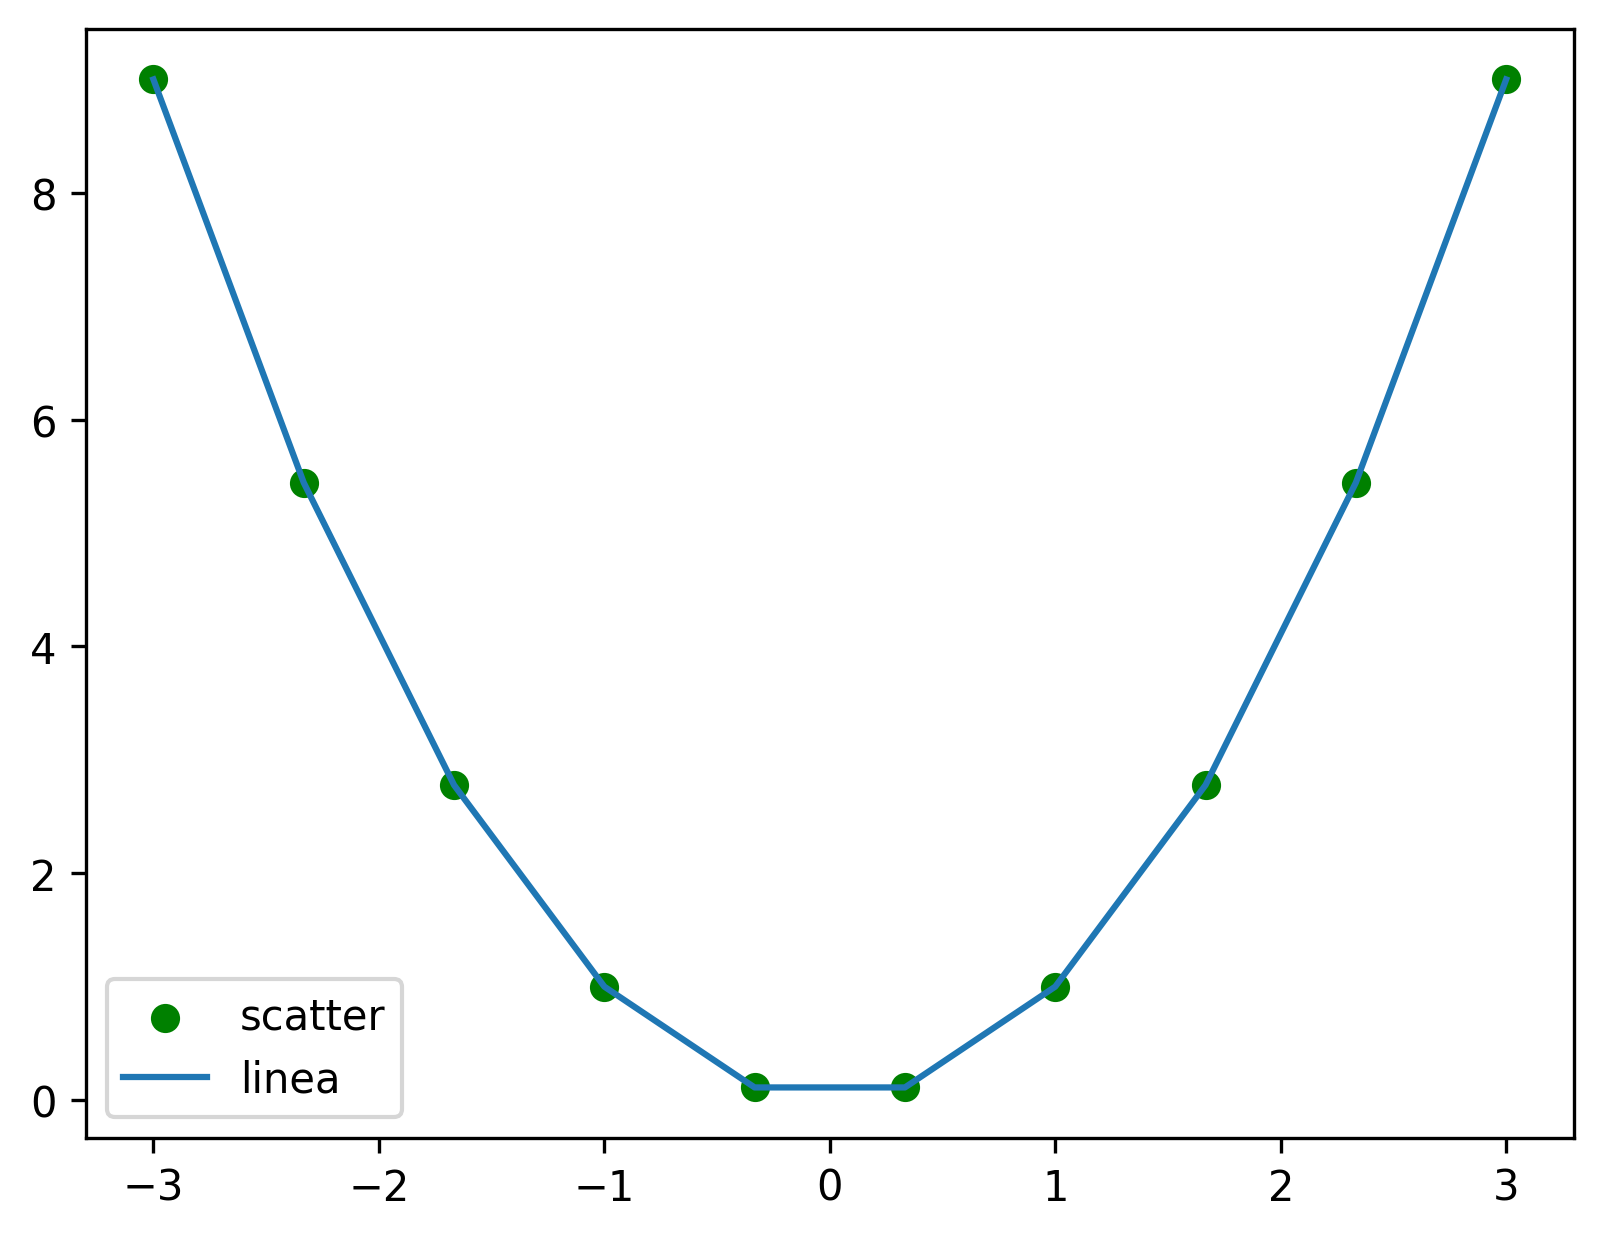

In [8]:
# grafico scatter y de linea
import matplotlib.pyplot as plt
x = np.linspace(-3, 3, 10) # genera 100 puntos entre -3 y 3
y =  x**2
fig, ax = plt.subplots(dpi = 300)
ax.scatter(x, y, label = 'scatter', c = 'green')
ax.plot(x, y, label = 'linea')
ax.legend()
plt.show()


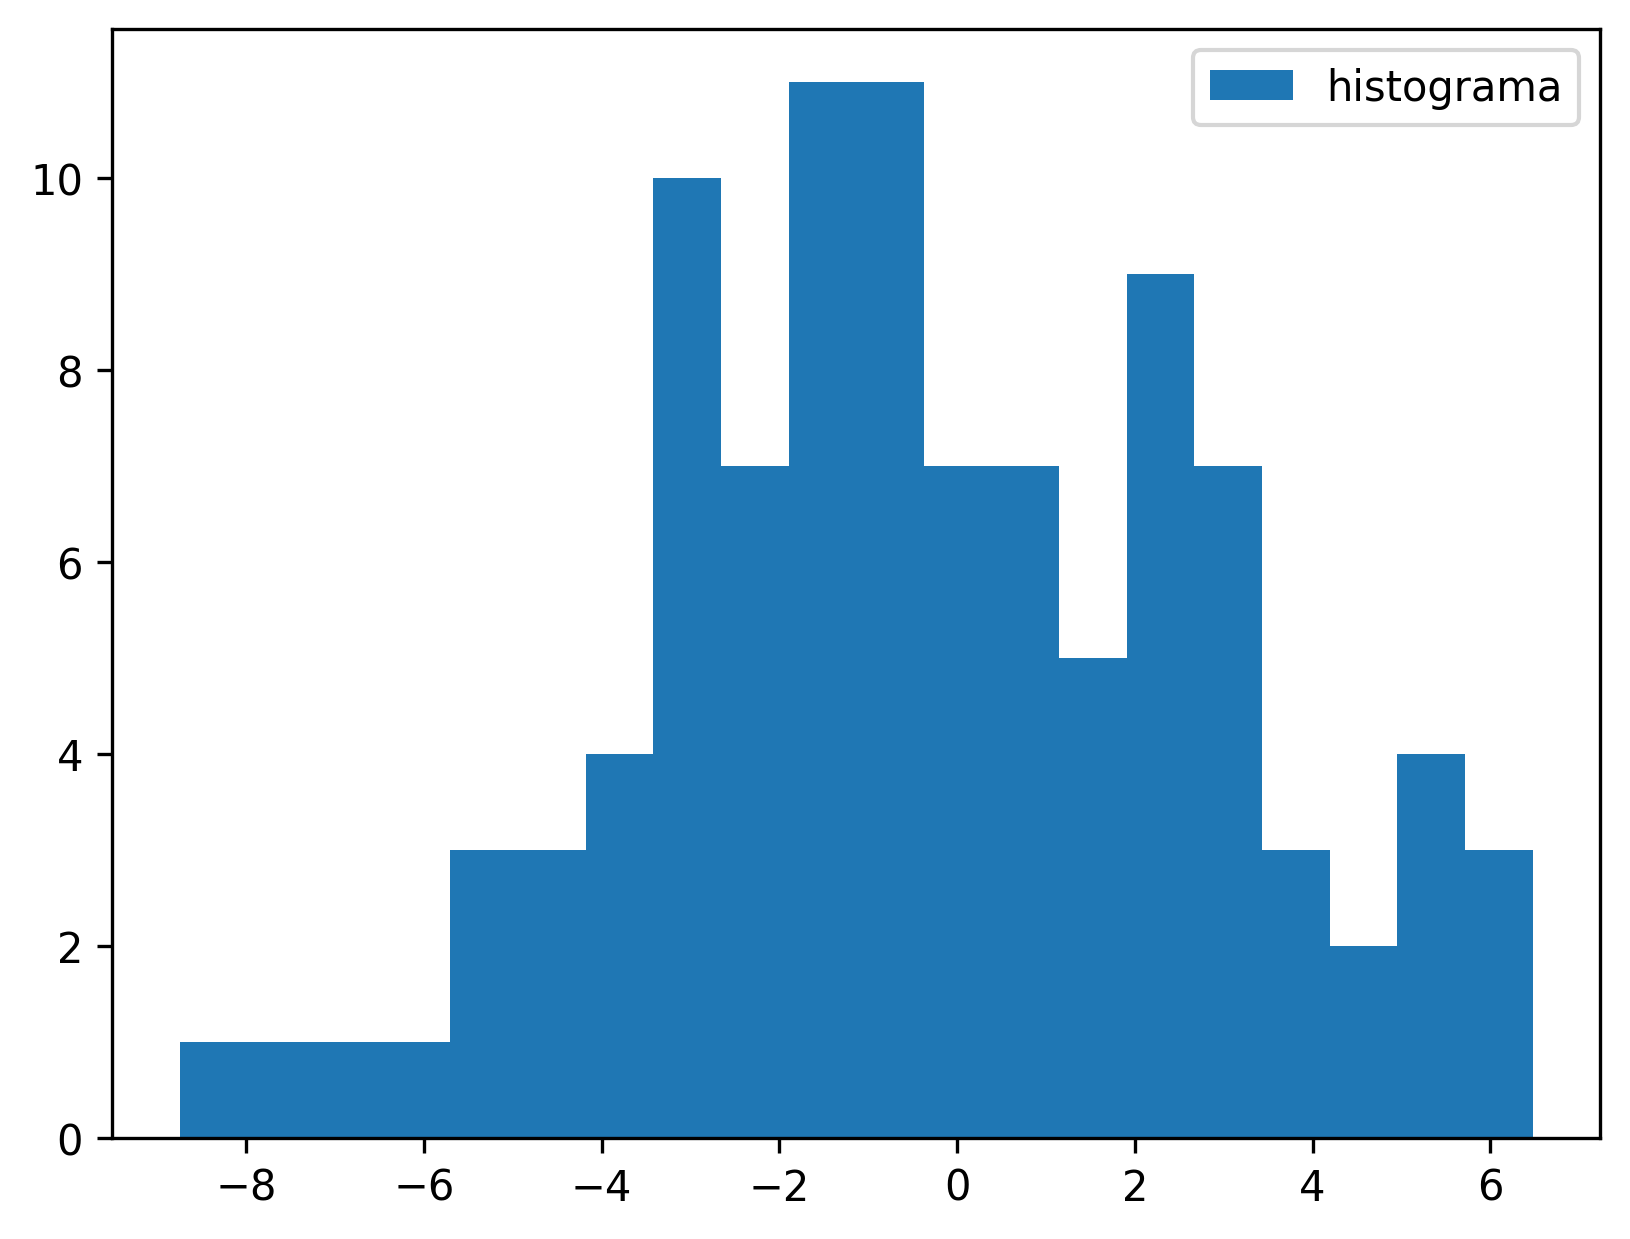

In [9]:
# histograma
np.random.seed(3)
x = np.random.normal(loc = 0, scale = 3,size =  100) # una normal media 1 y std 3
fig, ax = plt.subplots(dpi = 300)
ax.hist(x, bins = 20, label = 'histograma')
ax.legend()
plt.show()


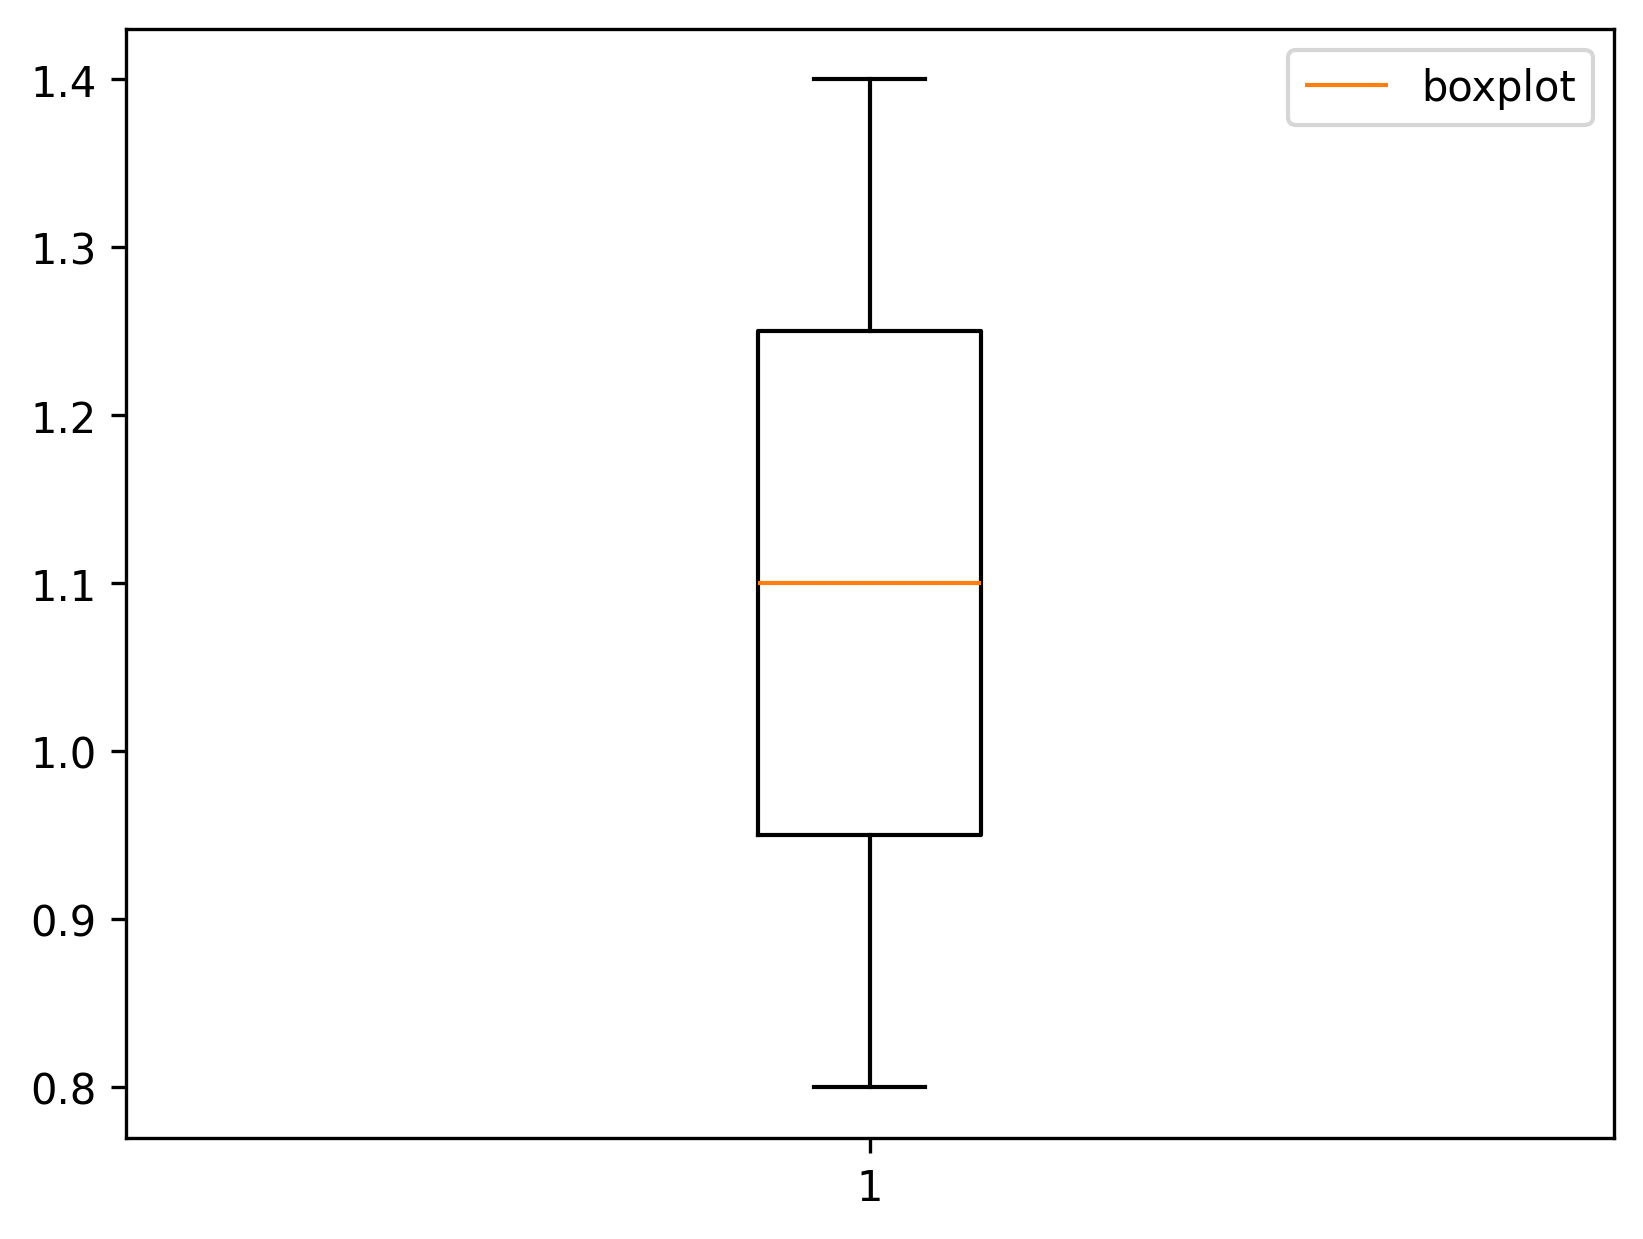

In [24]:
# boxplot
fig, ax = plt.subplots(dpi = 300)
ax.boxplot(x, label = 'boxplot')
ax.legend()
plt.show()


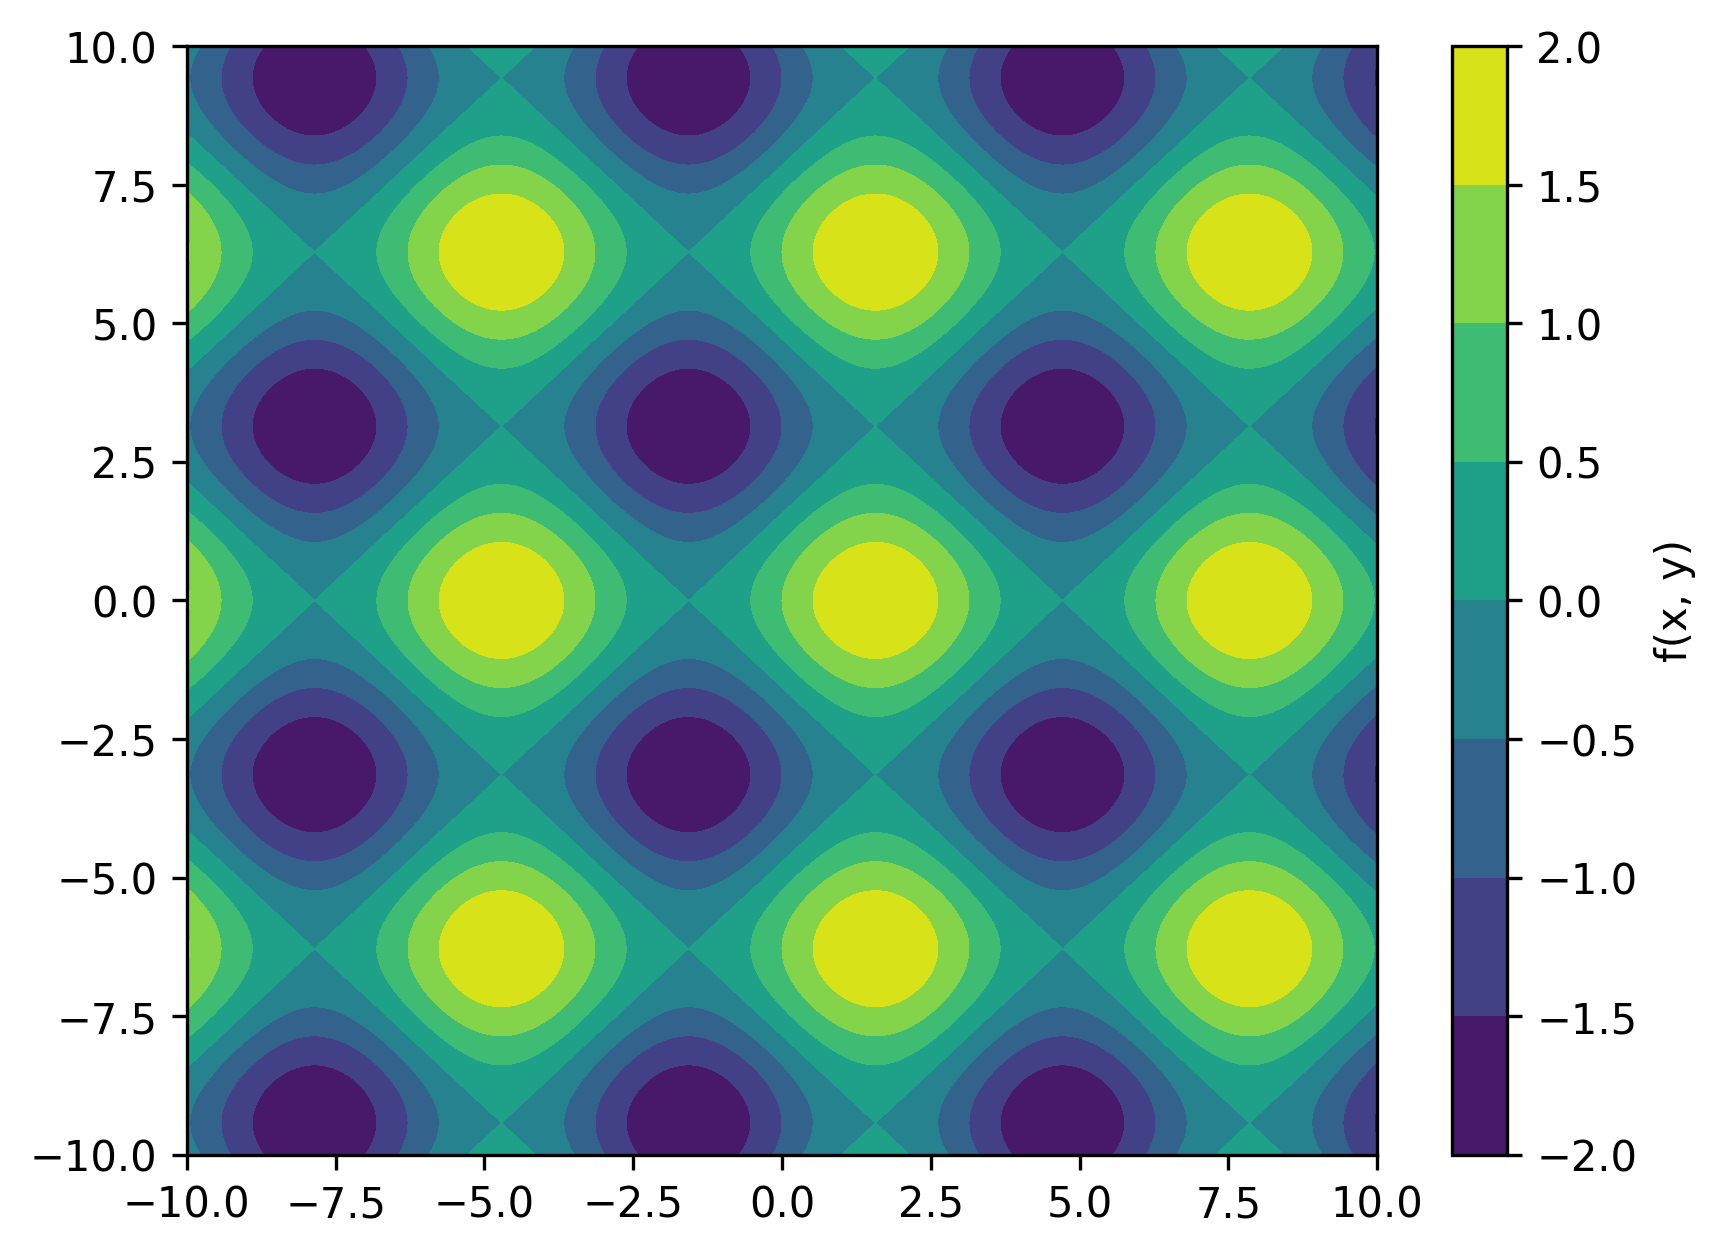

In [11]:
# grafico de contorno
x = np.linspace(-10, 10, 1000) # genera 100 puntos entre -3 y 3
y = np.linspace(-10, 10, 1000)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) + np.cos(Y)
fig, ax = plt.subplots(dpi = 300)
cont = ax.contourf(X, Y, Z)
fig.colorbar(cont, ax=ax, label = 'f(x, y)')
plt.show()


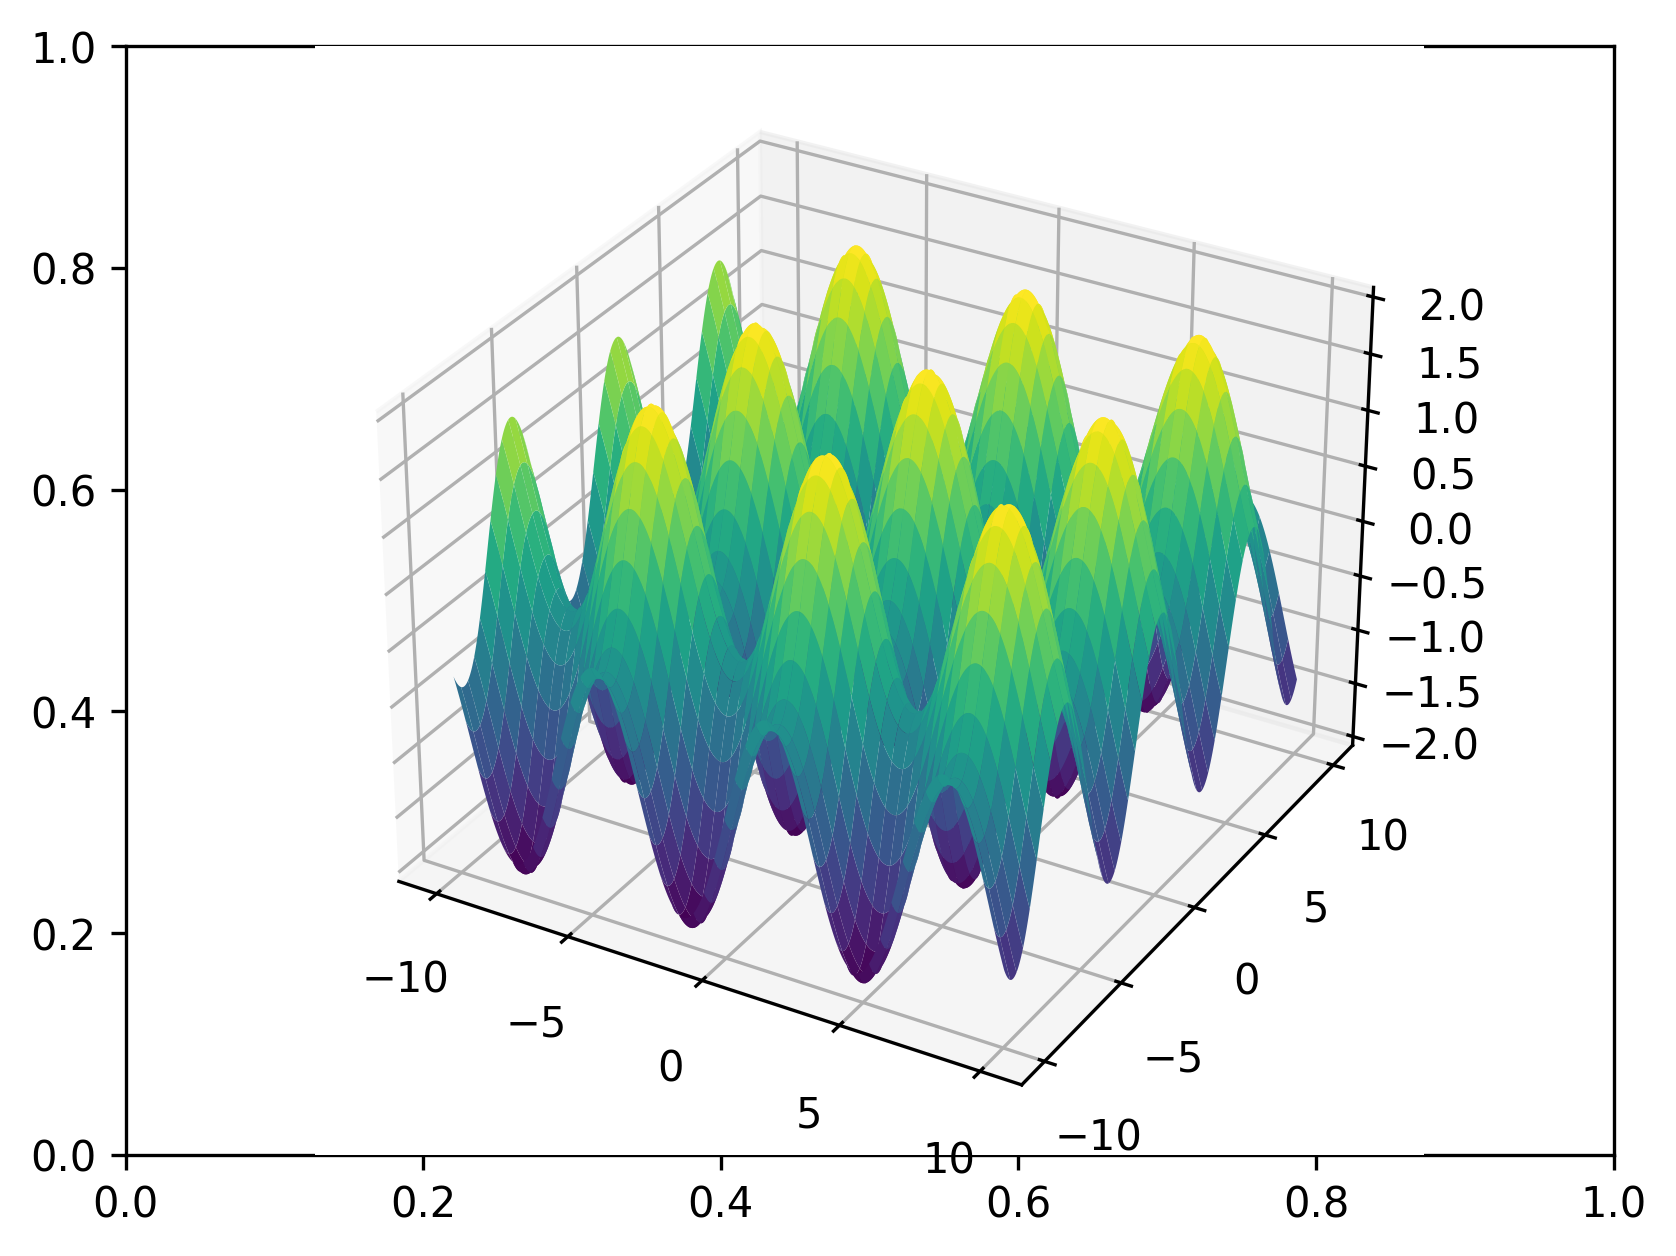

In [12]:
# grafico de contorno
x = np.linspace(-10, 10, 1000) # genera 100 puntos entre -3 y 3
y = np.linspace(-10, 10, 1000)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) + np.cos(Y)
fig, ax = plt.subplots(dpi = 300)
ax3d = fig.add_subplot(projection='3d')
ax3d.plot_surface(X, Y, Z, cmap='viridis')
plt.show()


## Optimización

Muchos problemas de ingeniería se reducen a encontrar el **mejor** valor de algo: el mínimo costo, el máximo rendimiento, los parámetros que mejor ajustan un modelo a datos experimentales, las condiciones de operación que minimizan el consumo energético, etc. Formalmente, esto se escribe como

$$
\min_{\mathbf{x}} f(\mathbf{x}) \quad \text{sujeto a} \quad g_i(\mathbf{x}) \le 0, \ \ h_j(\mathbf{x}) = 0
$$

donde $f$ es la **función objetivo**, y $g_i$, $h_j$ son las **restricciones** (de desigualdad e igualdad). En Python, la herramienta estándar para esto es `scipy.optimize`.


### Optimización sin restricciones

Partamos con el caso más simple: minimizar una función sin ninguna restricción. Usaremos `scipy.optimize.minimize`, que necesita la función a minimizar y un punto inicial `x0` desde donde empezar a buscar.

$$
f(x, y) = (x-3)^2 + (y+1)^2 + 5
$$

In [13]:
from scipy.optimize import minimize

def f(x):
    # x es un vector [x0, x1]
    return (x[0] - 3)**2 + (x[1] + 1)**2 + 5

x0 = [0, 0]  # punto de partida
resultado = minimize(f, x0)

print('x óptimo:', resultado.x)
print('f(x óptimo):', resultado.fun)


¿convergió? True
x óptimo: [ 3.00000027 -0.99999984]
f(x óptimo): 5.000000000000099


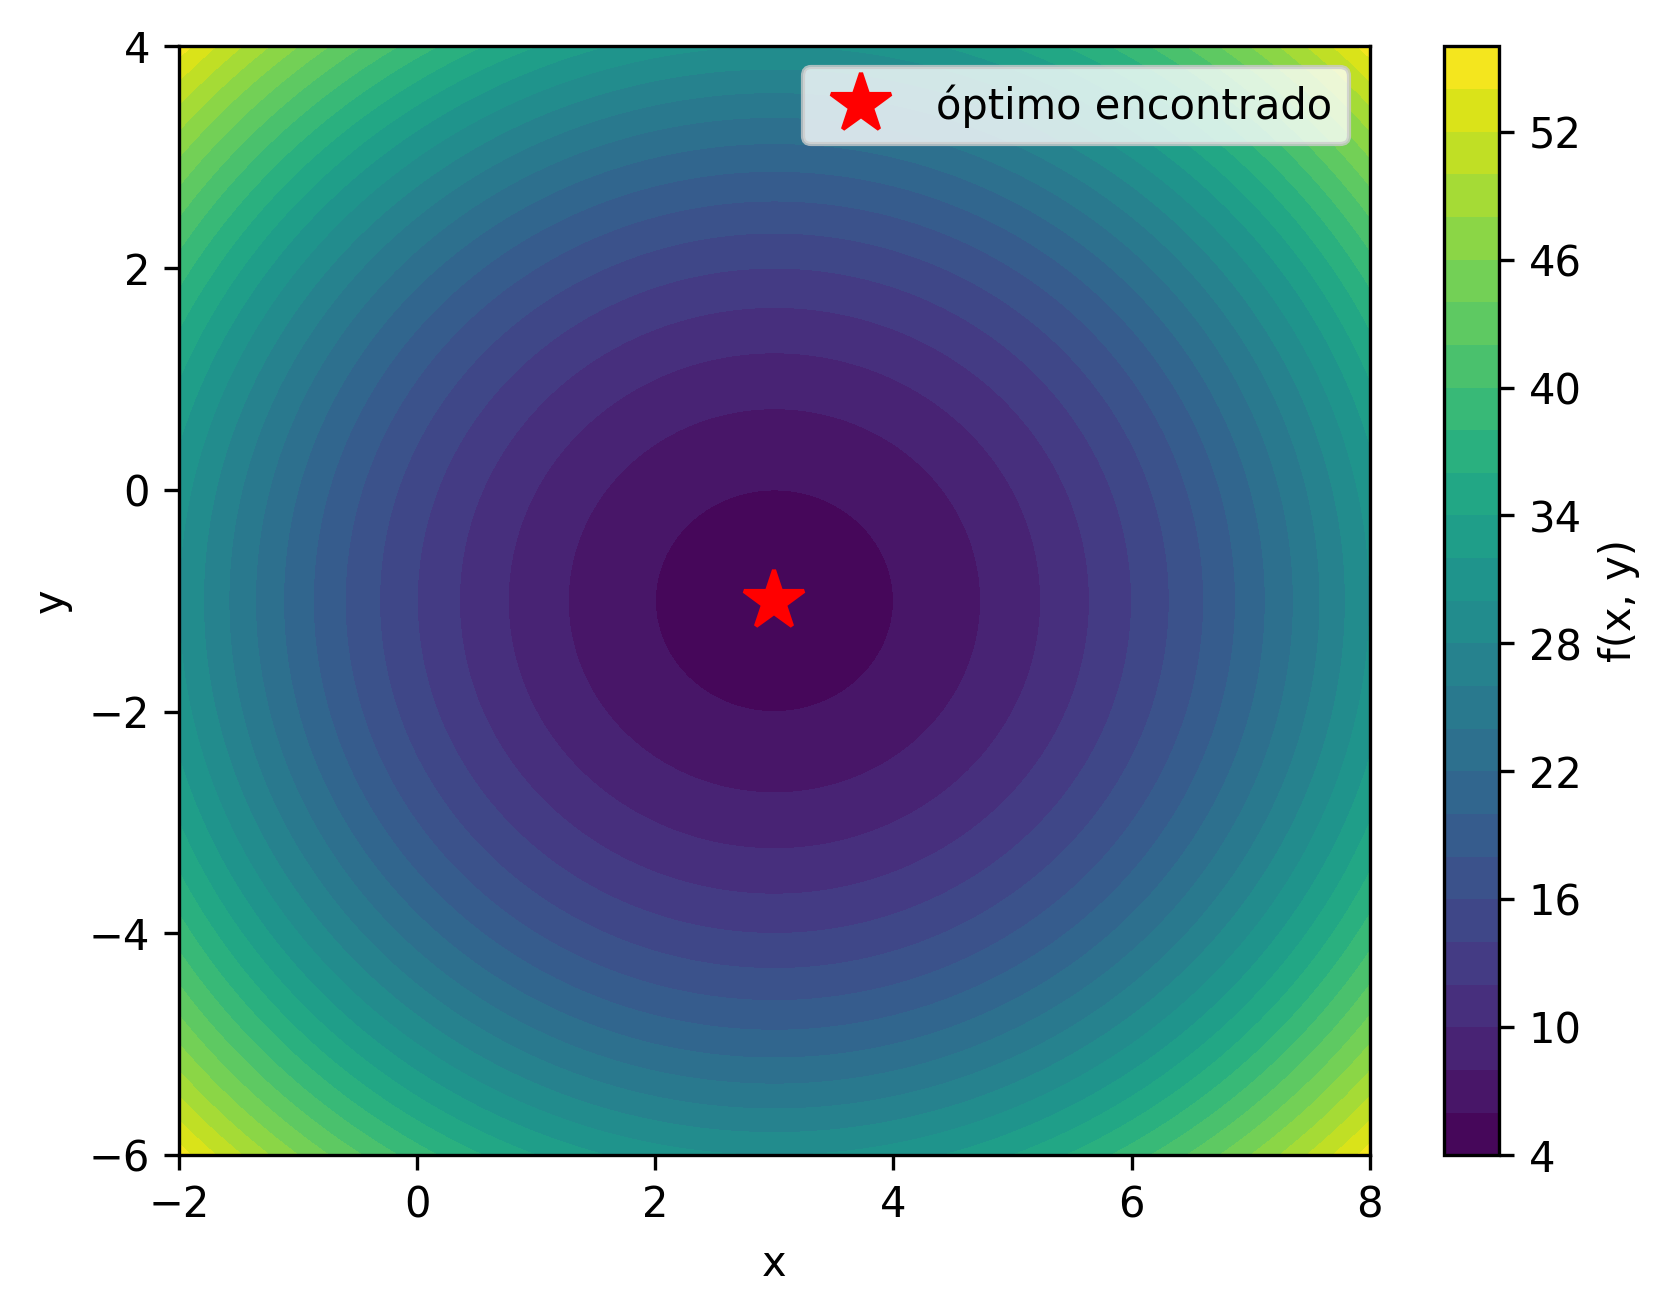

In [14]:
# visualicemos la función junto con el óptimo encontrado
x = np.linspace(-2, 8, 200)
y = np.linspace(-6, 4, 200)
X, Y = np.meshgrid(x, y)
Z = (X - 3)**2 + (Y + 1)**2 + 5

fig, ax = plt.subplots(dpi=300)
cont = ax.contourf(X, Y, Z, levels=25, cmap='viridis')
fig.colorbar(cont, ax=ax, label='f(x, y)')
ax.plot(*resultado.x, 'r*', markersize=15, label='óptimo encontrado')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.show()


### Optimización con restricciones

Ahora agreguemos restricciones. Supongamos que queremos minimizar la distancia al origen al cuadrado, pero forzando a que las dos variables sumen 10 (por ejemplo, dos flujos que deben repartirse un total fijo) y que ambas sean no negativas:

$$
\min_{x,y} \; x^2 + y^2 \qquad \text{s.a.} \qquad x + y = 10, \quad x,y \ge 0
$$

Las restricciones de desigualdad simples (como $x\ge0$) se pasan como `bounds`, y las más generales (como $x+y=10$) se pasan como `constraints`.


In [15]:
def f2(x):
    return x[0]**2 + x[1]**2

restriccion_igualdad = {
    'type': 'eq',
    'fun': lambda x: x[0] + x[1] - 10   # debe ser == 0
}

resultado2 = minimize(
    f2, x0=[1, 1],
    method='SLSQP',
    bounds=[(0, None), (0, None)],       # x >= 0, y >= 0
    constraints=[restriccion_igualdad],
)

print('x óptimo:', resultado2.x)
print('f(x óptimo):', resultado2.fun)


x óptimo: [5. 5.]
f(x óptimo): 49.99999999999997


### Programación lineal: `linprog`

Cuando tanto la función objetivo como todas las restricciones son **lineales**, conviene usar `scipy.optimize.linprog`, que está especializado en este tipo de problemas.

Ejemplo: una planta produce dos productos, $x_A$ y $x_B$, con una ganancia de \$3 y \$5 por unidad respectivamente. La producción está limitada por la capacidad de dos líneas y por una materia prima compartida:

$$
\begin{align}
\max\quad  &3x_A + 5x_B \qquad \\\text{s.a.} \quad
&x_A \le 4, \quad\\
&2x_B \le 12, \quad\\
&3x_A + 2x_B \le 18, \quad\\
&x_A, x_B \ge 0\\
\end{align}
$$

`linprog` solo sabe **minimizar**, así que para maximizar la ganancia minimizamos su negativo.


In [26]:
from scipy.optimize import linprog

c = [-3, -5]  # negativo porque linprog minimiza
A_ub = [[1, 0],
        [0, 2],
        [3, 2]]
b_ub = [4, 12, 18]

resultado3 = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None), (0, None)])

xA, xB = resultado3.x
ganancia = -resultado3.fun
print(f'producir xA={xA:.1f}, xB={xB:.1f}')
print(f'ganancia máxima: {ganancia:.1f}')


producir xA=2.0, xB=6.0
ganancia máxima: 36.0


# Evaluación de una función vectorial

Suponga que tiene la función
$$
f(\mathbf{x}) =\sqrt{\sum_{i=0}^n x_i^2}
$$

La cual se conoce como la norma-l2 de un vector. Determine el que puede tomar esta función para el vector $\mathbf{v}=[v_x, v_y]$ con $v_x\in[-3, 3]$ y $v_y=[0, 2]$.

---


Para trabajar con vectores en python, es posible usar el packete `numpy`, de esta forma, por ejemplo:


AttributeError: 'str' object has no attribute 'shape'

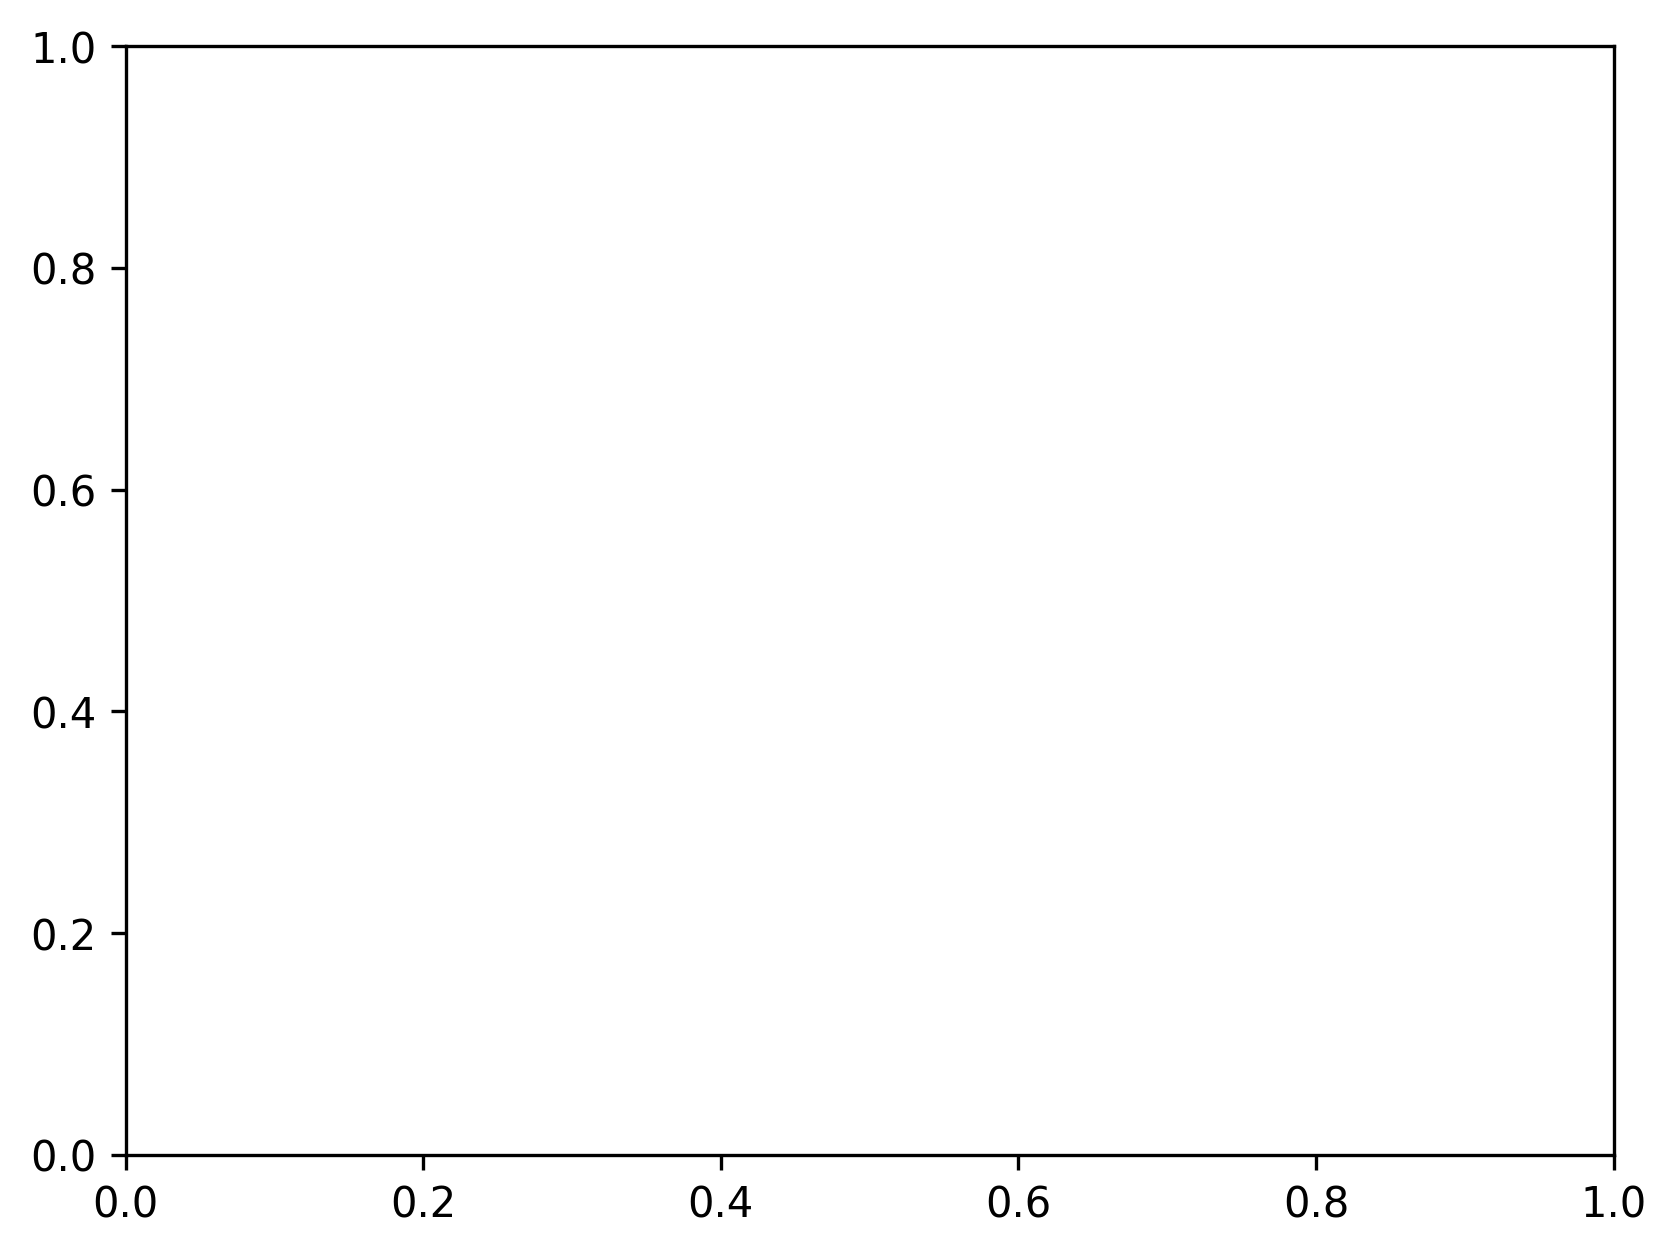

In [31]:
def computar_norma(v):
    valor = 'completar'
    return valor

def graficar_valores(vx, vy):
    fig, ax = plt.subplots(dpi = 300)
    shape = vx.shape[0]
    X = vx
    Y = vy
    X, Y = np.meshgrid(X, Y)
    valores = np.zeros((shape, shape))
    # rellenar valores usando un for loop
    cont = ax.contourf(X, Y, valores, levels = 20)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(cont, ax=ax, label = 'f(x, y)')
    plt.show()
# construyamos los valores del vector anterior
vx =  'completar' # completar
vy = 'completar' # completar


graficar_valores(vx, vy)


## Encontrar el mínimo con `scipy.optimize`

Ya graficaron $f(\mathbf{x})$ sobre la grilla. A simple vista uno sabe dónde está el mínimo de esta función , pero en problemas reales la función objetivo no siempre es tan simple, y no siempre se puede "ver" el mínimo en un gráfico.

Como ejercicio, completen lo siguiente para encontrar el mínimo de `computar_norma` de forma numérica con `scipy.optimize.minimize`, y comparen el resultado con lo que esperaban del gráfico.


In [32]:
from scipy.optimize import minimize

# punto inicial para la búsqueda (elijan uno distinto al mínimo esperado)
x0 = 'completar'

resultado_norma = minimize(computar_norma, x0)

print('x óptimo:', resultado_norma.x)
print('f(x óptimo):', resultado_norma.fun)
# ¿coincide con lo que esperaban al mirar el gráfico de contorno?


TypeError: '<' not supported between instances of 'str' and 'float'

## Resumen

| Tarea | Función |
|---|---|
| Producto punto | `np.dot(u, v)` o `u @ v` |
| Norma de un vector | `np.linalg.norm(v)` |
| Determinante / inversa / rango | `np.linalg.det`, `np.linalg.inv`, `np.linalg.matrix_rank` |
| Resolver $Ax=b$ (cuadrado) | `np.linalg.solve(A, b)` |
| Resolver $Ax=b$ (no cuadrado, mínimos cuadrados) | `np.linalg.lstsq(A, b)` |
| Valores y vectores propios | `np.linalg.eig(A)` |
| Número de condición | `np.linalg.cond(A)` |
| Optimización general (con o sin restricciones) | `scipy.optimize.minimize(f, x0, ...)` |
| Programación lineal | `scipy.optimize.linprog(c, A_ub, b_ub, ...)` |

Con esto ya tienen las piezas básicas de álgebra lineal y optimización para las próximas ayudantías.